#### This Notebook aims to implement techniques to create images used for detecting the presences of spurios features within image datasets. The priamry methods are currently derived from the following set of papers:

- Understanding Bias in Large-Scale Visual Datasets - https://arxiv.org/pdf/2412.01876v1
- Bias in Gender Bias Benchmarks: How Spurious Features Distort Evaluation - https://arxiv.org/pdf/2509.07596
- Gender Artifacts in Visual Datasets - https://arxiv.org/pdf/2206.09191

In [1]:
import torch
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation
from PIL import Image
import numpy as np

#### Semantic Segmentation

- Method derived from "Understanding Bias in Large-Scale Visual Datasets" 

In [5]:
# Load model and feature extractor once
model_name = "IDEA-Research/ViT-Adapter-Large-ADE20K"
feature_extractor = SegformerFeatureExtractor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)
model.eval()

def segment_image(image_path):
    """
    Given a path to an image, returns a color-coded segmentation mask (PIL Image).
    """
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    inputs = feature_extractor(images=image, return_tensors="pt")

    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_mask = outputs.logits.argmax(dim=1)[0].cpu().numpy()

    # Use the model's built-in palette
    palette = np.array(feature_extractor.get("palette"))

    # Map predicted mask to RGB colors
    segmentation_rgb = palette[predicted_mask]
    segmentation_image = Image.fromarray(segmentation_rgb.astype(np.uint8))

    return segmentation_image

# Example usage:
# mask_image = segment_image("path/to/your/image.jpg")
# mask_image.show()


c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv - Copy - Copy\lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


OSError: IDEA-Research/ViT-Adapter-Large-ADE20K is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

#### Downloading the ViT-Adapter ADE20K Segmentation Model & Config File
- This is the same model used in "Understanding Bias in Large-Scale Visual Datasets" paper using the same URL as per the [Github](https://github.com/boyazeng/understand_bias/blob/main/transformations/semantic_seg/README.md) repo.
- Download code takes 12 minutes to execute.

In [15]:
import os
import urllib.request
import zipfile

# Directory to store the model and config
model_dir = "segmentation"
os.makedirs(model_dir, exist_ok=True)

# ------------------ Files to download ------------------
checkpoint_file = os.path.join(model_dir, "mask2former_beitv2_adapter_large_896_80k_ade20k.pth")
zip_file = os.path.join(model_dir, "mask2former_beitv2_adapter_large_896_80k_ade20k.zip")
zip_url = "https://github.com/czczup/ViT-Adapter/releases/download/v0.3.1/mask2former_beitv2_adapter_large_896_80k_ade20k.zip"

config_file = os.path.join(model_dir, "mask2former_beitv2_adapter_large_896_80k_ade20k_ss.py")
config_url = "https://raw.githubusercontent.com/czczup/ViT-Adapter/main/segmentation/configs/ade20k/mask2former_beitv2_adapter_large_896_80k_ade20k_ss.py"

# ------------------ Download checkpoint if needed ------------------
if not os.path.exists(checkpoint_file):
    print("Checkpoint not found. Downloading...")
    
    # Download zip
    urllib.request.urlretrieve(zip_url, zip_file)
    print(f"Downloaded zip file to {zip_file}")

    # Unzip
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(model_dir)
    print(f"Extracted files to {model_dir}")

    # Delete zip
    os.remove(zip_file)
    print("Deleted the zip file after extraction.")
else:
    print("Checkpoint already exists. Skipping download.")

# ------------------ Download config if needed ------------------
if not os.path.exists(config_file):
    print("Config file not found. Downloading...")
    urllib.request.urlretrieve(config_url, config_file)
    print(f"Downloaded config to {config_file}")
else:
    print("Config file already exists. Skipping download.")


Checkpoint already exists. Skipping download.
Config file not found. Downloading...
Downloaded config to segmentation\mask2former_beitv2_adapter_large_896_80k_ade20k_ss.py


In [29]:
import os
import urllib.request
import zipfile

# Base directory for segmentation files
seg_dir = "segmentation"
os.makedirs(seg_dir, exist_ok=True)

# ------------------ Config file ------------------
config_file_name = "mask2former_beitv2_adapter_large_896_80k_ade20k_ss.py"
config_file_path = os.path.join(seg_dir, "configs/ade20k", config_file_name)
os.makedirs(os.path.dirname(config_file_path), exist_ok=True)

config_url = f"https://raw.githubusercontent.com/czczup/ViT-Adapter/main/segmentation/configs/ade20k/{config_file_name}"

# Download config if not exists
if not os.path.exists(config_file_path):
    print(f"Downloading config file to {config_file_path}...")
    urllib.request.urlretrieve(config_url, config_file_path)
    print("Config downloaded.")
else:
    print("Config already exists. Skipping download.")

# ------------------ _base_ directory ------------------
# List of files in _base_ required by this config
base_files = [
    "models/mask2former_beit.py",
    "datasets/ade20k.py",
    "schedules/schedule_80k.py",
    "default_runtime.py"
]

for f in base_files:
    file_path = os.path.join(seg_dir, "configs/_base_", f)
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    file_url = f"https://raw.githubusercontent.com/czczup/ViT-Adapter/main/segmentation/configs/_base_/{f}"
    
    if not os.path.exists(file_path):
        print(f"Downloading _base_ file {f}...")
        urllib.request.urlretrieve(file_url, file_path)
        print(f"{f} downloaded.")
    else:
        print(f"{f} already exists. Skipping download.")

# ------------------ mmseg_custom directory ------------------
custom_files = [
    "models/segmentors/encoder_decoder_mask2former.py",
    "models/backbones/vit_adapter.py",
    # "models/heads/mask2former_head.py",
    # "models/necks/decoder.py",
    # "models/utils.py"
]

for f in custom_files:
    file_path = os.path.join(seg_dir, "mmseg_custom", f)
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    file_url = f"https://raw.githubusercontent.com/czczup/ViT-Adapter/main/segmentation/mmseg_custom/{f}"
    
    if not os.path.exists(file_path):
        print(f"Downloading mmseg_custom file {f}...")
        urllib.request.urlretrieve(file_url, file_path)
        print(f"{f} downloaded.")
    else:
        print(f"{f} already exists. Skipping download.")

# ------------------ Model checkpoint ------------------
checkpoint_file = os.path.join(seg_dir, "mask2former_beitv2_adapter_large_896_80k_ade20k.pth")
zip_file = os.path.join(seg_dir, "mask2former_beitv2_adapter_large_896_80k_ade20k.zip")
zip_url = "https://github.com/czczup/ViT-Adapter/releases/download/v0.3.1/mask2former_beitv2_adapter_large_896_80k_ade20k.zip"

if not os.path.exists(checkpoint_file):
    print("Checkpoint not found. Downloading...")
    
    # Download zip
    urllib.request.urlretrieve(zip_url, zip_file)
    print(f"Downloaded zip file to {zip_file}")

    # Unzip
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(seg_dir)
    print(f"Extracted files to {seg_dir}")

    # Delete zip
    os.remove(zip_file)
    print("Deleted the zip file after extraction.")
else:
    print("Checkpoint already exists. Skipping download.")


Config already exists. Skipping download.
models/mask2former_beit.py already exists. Skipping download.
datasets/ade20k.py already exists. Skipping download.
schedules/schedule_80k.py already exists. Skipping download.
default_runtime.py already exists. Skipping download.
models/segmentors/encoder_decoder_mask2former.py already exists. Skipping download.
models/backbones/vit_adapter.py already exists. Skipping download.
Checkpoint already exists. Skipping download.


In [ ]:
# !pip install mmsegmentation

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.4 MB 12.5 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 9.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]
   -------------------- ------------------- 1/2 [mmsegmentation]


In [ ]:
# !pip install mmcv==2.1.0

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for mmcv: filename=mmcv-2.1.0-cp310-cp310-win_amd64.whl size=9486627 sha256=de07d8f1f6c9c0b6ec65f45660a62d7068098f083c6e34bd0ef4cbc3d4022a81
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\8b\09\35\94a7f7ba6a00e3810abd0492340e4cbba0ff3d443120a94120
Successfully built mmcv
  Attempting uninstall: mmcv
    Found existing installation: mmcv 2.2.0
    Uninstalling mmcv-2.2.0:
      Successfully uninstalled mmcv-2.2.0


  DEPRECATION: Building 'mmcv' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'mmcv'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [5]:
import numpy as np

# Patch np.float_ to np.float64 for compatibility with NumPy 2.0
np.float_ = np.float64
np.float = np.float64

import sys
import os

# --- Add this block of code ---
# Define the path to the 'segmentation' folder (the parent of both 'mmseg_custom' and 'ops')
segmentation_root = "segmentation"
if segmentation_root not in sys.path:
    # This is the crucial line: it allows Python to find 'ops.modules'
    sys.path.insert(0, segmentation_root)
# ------------------------------

# Path to the mmseg_custom directory (your existing code)
mmseg_custom_dir = os.path.join(segmentation_root, "mmseg_custom")
if mmseg_custom_dir not in sys.path:
    sys.path.insert(0, mmseg_custom_dir)

# Import all custom modules to register them
# This will now successfully resolve 'from ops.modules' inside vit_adapter.py
import models.segmentors.encoder_decoder_mask2former
import models.backbones.vit_adapter
import models.heads.mask2former_head

# Path to the mmseg_custom directory
mmseg_custom_dir = os.path.join("segmentation", "mmseg_custom")
if mmseg_custom_dir not in sys.path:
    sys.path.insert(0, mmseg_custom_dir)

# Import all custom modules to register them
import models.segmentors.encoder_decoder_mask2former
import models.backbones.vit_adapter
import models.heads.mask2former_head



import torch
import mmcv
from mmseg.apis import init_segmentor, inference_segmentor
from mmseg.core import get_classes, get_palette
from PIL import Image
import numpy as np



# --------- Initialize the model once ---------
CONFIG_FILE = 'segmentation/configs/ade20k/mask2former_beitv2_adapter_large_896_80k_ade20k_ss.py'
CHECKPOINT_FILE = 'segmentation/mask2former_beitv2_adapter_large_896_80k_ade20k.pth'
DEVICE = 'cuda'  # or 'cpu'

cfg = mmcv.Config.fromfile(CONFIG_FILE)
cfg.model.pretrained = None
cfg.model.train_cfg = None
model = init_segmentor(cfg, checkpoint=None, device=DEVICE)
_ = torch.load(CHECKPOINT_FILE, map_location='cpu')
checkpoint = torch.load(CHECKPOINT_FILE, map_location='cpu')
model.CLASSES = get_classes('ade')
COLOR_MAPPING = get_palette('ade')
model.eval()

def segment_image_mmseg(image_path):
    """
    Given a path to an image, returns a PIL Image of the color-coded segmentation mask.
    """
    # Load image
    image = mmcv.imread(image_path)

    # Run inference
    result = inference_segmentor(model, image)
    mask = result[0]

    # Map mask to color
    h, w = mask.shape
    seg_image = np.ones((h, w, 3), dtype=np.uint8) * 255
    for k in range(len(model.CLASSES)):
        seg_image[mask == k] = COLOR_MAPPING[k]

    seg_image = Image.fromarray(seg_image)
    return seg_image




ImportError: DLL load failed while importing MultiScaleDeformableAttention: The specified module could not be found.

In [2]:
# import numpy as np

# # Patch np.float_ for NumPy 2.0 compatibility
# np.float_ = np.float64
# np.float = np.float64


# import sys
# import os

# # Add mmseg_custom to Python path
# mmseg_custom_dir = os.path.abspath("segmentation/mmseg_custom")
# if mmseg_custom_dir not in sys.path:
#     sys.path.insert(0, mmseg_custom_dir)

# # Import all custom modules to register them in MMSEG
# import models.segmentors.encoder_decoder_mask2former
# import models.backbones.vit_adapter
# import models.heads.mask2former_head
# import models.necks.decoder
# import models.utils


import torch
import mmcv
from mmseg.apis import init_model, inference_model
from PIL import Image

# --------- Initialize the model once ---------
CONFIG_FILE = 'segmentation/configs/ade20k/mask2former_beitv2_adapter_large_896_80k_ade20k_ss.py'
CHECKPOINT_FILE = 'segmentation/mask2former_beitv2_adapter_large_896_80k_ade20k.pth'
DEVICE = 'cuda'  # or 'cpu'

# Initialize model
model = init_model(CONFIG_FILE, CHECKPOINT_FILE, device=DEVICE)
model.eval()

# --- Get classes and palette from model config ---
CLASSES = model.cfg.get('classes', None)
if CLASSES is None:
    # Default ADE20K 150 classes
    CLASSES = [f'class_{i}' for i in range(150)]

# Default ADE20K palette
PALETTE = model.cfg.get('palette', None)
if PALETTE is None:
    # 150-class ADE20K color palette (standard)
    from mmseg.datasets.builder import DATASETS
    from mmseg.datasets.ade20k import ADE20KDataset
    PALETTE = ADE20KDataset.PALETTE


def segment_image_mmseg(image_path):
    """
    Given a path to an image, returns a PIL Image of the color-coded segmentation mask.
    """
    # Load image
    image = mmcv.imread(image_path)

    # Run inference
    result = inference_model(model, image)

    # Extract predicted mask (pred_sem_seg)
    if hasattr(result[0], 'pred_sem_seg') and result[0].pred_sem_seg is not None:
        mask = result[0].pred_sem_seg.argmax(dim=0).cpu().numpy()
    else:
        mask = result[0]

    # Map mask to color
    h, w = mask.shape
    seg_image = np.ones((h, w, 3), dtype=np.uint8) * 255
    for k in range(len(CLASSES)):
        seg_image[mask == k] = PALETTE[k]

    return Image.fromarray(seg_image)


ImportError: cannot import name 'init_model' from 'mmseg.apis' (c:\Users\User\anaconda3\envs\bias_seg\lib\site-packages\mmseg\apis\__init__.py)

In [ ]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
import torch
from PIL import Image, ImageDraw, ImageFont
import requests
from io import BytesIO
import numpy as np

# ---------------- Load your image ----------------
url = "https://images.unsplash.com/photo-1520337437121-5496ea83b82d?fm=jpg&q=60&w=3000"
response = requests.get(url)
image = Image.open(BytesIO(response.content))
image.show(title="Original Image")

# ---------------- Load the model ----------------
processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-large-ade-semantic")
model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-large-ade-semantic")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()
print(f"Running on device: {device}")

# ---------------- Run inference ----------------
inputs = processor(images=image, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

# ---------------- Get semantic segmentation map ----------------
pred_semantic_map = processor.post_process_semantic_segmentation(
    outputs, target_sizes=[(image.height, image.width)]
)[0].cpu().numpy()

# ---------------- ADE20K palette ----------------
ade_palette = np.array([
    [120, 120, 120], [180, 120, 120], [6, 230, 230], [80, 50, 50],
    [4, 200, 3], [120, 120, 80], [140, 140, 140], [204, 5, 255],
    [230, 230, 230], [4, 250, 7], [224, 5, 255], [235, 255, 7],
    [150, 5, 61], [120, 120, 70], [8, 255, 51], [255, 6, 82],
    [143, 255, 140], [204, 255, 4], [255, 51, 7], [204, 70, 3],
    [0, 102, 200], [61, 230, 250], [255, 6, 51], [11, 102, 255],
    [255, 7, 71], [255, 9, 224], [9, 7, 230], [220, 220, 220],
    [255, 9, 92], [112, 9, 255], [8, 255, 214], [7, 255, 224],
    [255, 184, 6], [10, 255, 71], [255, 41, 10], [7, 255, 255],
    [224, 255, 8], [102, 8, 255], [255, 61, 6], [255, 194, 7],
    [255, 122, 8], [0, 255, 20], [255, 8, 41], [255, 5, 153],
    [6, 51, 255], [235, 12, 255], [160, 150, 20], [0, 163, 255],
    [140, 140, 140], [250, 10, 15], [20, 255, 0], [31, 255, 0],
    [255, 31, 0], [255, 224, 0], [153, 255, 0], [0, 0, 255],
    [255, 71, 0], [0, 235, 255], [0, 173, 255], [31, 0, 255],
    [11, 200, 200], [255, 82, 0], [0, 255, 245], [0, 61, 255],
    [0, 255, 112], [0, 255, 133], [255, 0, 0], [255, 163, 0],
    [255, 102, 0], [194, 255, 0], [0, 143, 255], [51, 255, 0],
    [0, 82, 255], [0, 255, 41], [0, 255, 173], [10, 0, 255],
    [173, 255, 0], [0, 255, 153], [255, 92, 0], [255, 0, 255],
    [255, 0, 245], [255, 0, 102], [255, 173, 0], [255, 0, 20],
    [255, 184, 184], [0, 31, 255], [0, 255, 61], [0, 71, 255],
    [255, 0, 204], [0, 255, 194], [0, 255, 82], [0, 10, 255],
    [0, 112, 255], [51, 0, 255], [0, 194, 255], [0, 122, 255],
    [0, 255, 163], [255, 153, 0], [0, 255, 10], [255, 112, 0],
    [143, 255, 0], [82, 0, 255], [163, 255, 0], [255, 235, 0],
    [8, 184, 170], [133, 0, 255], [0, 255, 92], [184, 0, 255],
    [255, 0, 31], [0, 184, 255], [0, 214, 255], [255, 0, 112],
    [92, 255, 0], [0, 224, 255], [112, 224, 255], [70, 184, 160],
    [163, 0, 255], [153, 0, 255], [71, 255, 0], [255, 0, 163],
    [255, 204, 0], [255, 0, 143], [0, 255, 235], [133, 255, 0],
    [255, 0, 235], [245, 0, 255], [255, 0, 122], [255, 245, 0],
    [10, 190, 212], [214, 255, 0], [0, 204, 255], [20, 0, 255],
    [255, 255, 255], [0, 0, 0], [128, 128, 128], [64, 64, 64],
    [192, 192, 192], [128, 0, 0], [128, 128, 0], [0, 128, 0],
    [128, 0, 128], [0, 128, 128], [0, 0, 128], [255, 165, 0],
    [255, 215, 0], [173, 216, 230], [199, 21, 133], [0, 191, 255]
], dtype=np.uint8)


# ---------------- Create segmented image (vectorized) ----------------
seg_image = ade_palette[pred_semantic_map]  # fast vectorized mapping
seg_image_pil = Image.fromarray(seg_image)
seg_image_pil.show(title="Segmented Image")

# ---------------- Create legend image ----------------
unique_indices = np.unique(pred_semantic_map)
legend_height = 25 * len(unique_indices) + 10
legend_img = Image.new("RGB", (300, legend_height), color=(255, 255, 255))
draw = ImageDraw.Draw(legend_img)
font = ImageFont.load_default()

for i, idx in enumerate(unique_indices):
    color = tuple(ade_palette[idx])
    draw.rectangle([5, 5 + 25*i, 25, 25 + 25*i], fill=color)
    draw.text((30, 5 + 25*i), model.config.id2label[idx], fill=(0, 0, 0), font=font)

legend_img.show(title="Legend")


c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv - Copy - Copy\lib\site-packages\huggingface_hub\file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Running on device: cuda


In [ ]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
import torch
from PIL import Image
import numpy as np

# ---------------- ADE20K palette (vectorized) ----------------
ADE_PALETTE = np.array([
    [120, 120, 120], [180, 120, 120], [6, 230, 230], [80, 50, 50],
    [4, 200, 3], [120, 120, 80], [140, 140, 140], [204, 5, 255],
    [230, 230, 230], [4, 250, 7], [224, 5, 255], [235, 255, 7],
    [150, 5, 61], [120, 120, 70], [8, 255, 51], [255, 6, 82],
    [143, 255, 140], [204, 255, 4], [255, 51, 7], [204, 70, 3],
    [0, 102, 200], [61, 230, 250], [255, 6, 51], [11, 102, 255],
    [255, 7, 71], [255, 9, 224], [9, 7, 230], [220, 220, 220],
    [255, 9, 92], [112, 9, 255], [8, 255, 214], [7, 255, 224],
    [255, 184, 6], [10, 255, 71], [255, 41, 10], [7, 255, 255],
    [224, 255, 8], [102, 8, 255], [255, 61, 6], [255, 194, 7],
    [255, 122, 8], [0, 255, 20], [255, 8, 41], [255, 5, 153],
    [6, 51, 255], [235, 12, 255], [160, 150, 20], [0, 163, 255],
    [140, 140, 140], [250, 10, 15], [20, 255, 0], [31, 255, 0],
    [255, 31, 0], [255, 224, 0], [153, 255, 0], [0, 0, 255],
    [255, 71, 0], [0, 235, 255], [0, 173, 255], [31, 0, 255],
    [11, 200, 200], [255, 82, 0], [0, 255, 245], [0, 61, 255],
    [0, 255, 112], [0, 255, 133], [255, 0, 0], [255, 163, 0],
    [255, 102, 0], [194, 255, 0], [0, 143, 255], [51, 255, 0],
    [0, 82, 255], [0, 255, 41], [0, 255, 173], [10, 0, 255],
    [173, 255, 0], [0, 255, 153], [255, 92, 0], [255, 0, 255],
    [255, 0, 245], [255, 0, 102], [255, 173, 0], [255, 0, 20],
    [255, 184, 184], [0, 31, 255], [0, 255, 61], [0, 71, 255],
    [255, 0, 204], [0, 255, 194], [0, 255, 82], [0, 10, 255],
    [0, 112, 255], [51, 0, 255], [0, 194, 255], [0, 122, 255],
    [0, 255, 163], [255, 153, 0], [0, 255, 10], [255, 112, 0],
    [143, 255, 0], [82, 0, 255], [163, 255, 0], [255, 235, 0],
    [8, 184, 170], [133, 0, 255], [0, 255, 92], [184, 0, 255],
    [255, 0, 31], [0, 184, 255], [0, 214, 255], [255, 0, 112],
    [92, 255, 0], [0, 224, 255], [112, 224, 255], [70, 184, 160],
    [163, 0, 255], [153, 0, 255], [71, 255, 0], [255, 0, 163],
    [255, 204, 0], [255, 0, 143], [0, 255, 235], [133, 255, 0],
    [255, 0, 235], [245, 0, 255], [255, 0, 122], [255, 245, 0],
    [10, 190, 212], [214, 255, 0], [0, 204, 255], [20, 0, 255],
    [255, 255, 255], [0, 0, 0], [128, 128, 128], [64, 64, 64],
    [192, 192, 192], [128, 0, 0], [128, 128, 0], [0, 128, 0],
    [128, 0, 128], [0, 128, 128], [0, 0, 128], [255, 165, 0],
    [255, 215, 0], [173, 216, 230], [199, 21, 133], [0, 191, 255]
], dtype=np.uint8)


def segment_image(model, processor, image_path):
    """
    Segments a local image using a Mask2Former model and returns a colored segmented PIL image.
    
    Args:
        model: Mask2FormerForUniversalSegmentation model (preloaded)
        image_path: str, path to local image file

    Returns:
        seg_image_pil: PIL.Image.Image, segmented image with ADE20K colors
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    # Load image
    image = Image.open(image_path)

    # Run inference
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    # Semantic segmentation map
    pred_semantic_map = processor.post_process_semantic_segmentation(
        outputs, target_sizes=[(image.height, image.width)]
    )[0].cpu().numpy()

    # Apply ADE20K palette (vectorized)
    seg_image = ADE_PALETTE[pred_semantic_map]
    seg_image_pil = Image.fromarray(seg_image)

    return seg_image_pil

# ---------------- Example usage ----------------
model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-large-ade-semantic")
processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-large-ade-semantic")
segmented_image = segment_image(model, processor, r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a car_1 - Copy.png")
segmented_image.show()

### Semantic Segmentation

In [ ]:
# import matplotlib._color_data as mcd

# def get_palette(dataset_name):
#     if dataset_name == 'ade':
#         return mcd.TABLEAU_COLORS
#     else:
#         raise ValueError(f"Unknown dataset: {dataset_name}")

In [ ]:
# colors = mcd.CSS4_COLORS
# color_keys = list(colors.keys())
# len(color_keys)

148

In [28]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
import torch
from PIL import Image
import numpy as np
from typing import List, Union
from tqdm import tqdm

# ---------------- ADE20K palette (vectorized) ----------------
ADE_PALETTE = np.array([
    (120, 120, 120), (180, 120, 120), (6, 230, 230), (80, 50, 50),
    (4, 200, 3), (120, 120, 80), (140, 140, 140), (204, 5, 255),
    (230, 230, 230), (4, 250, 7), (224, 5, 255), (235, 255, 7),
    (150, 5, 61), (120, 120, 70), (8, 255, 51), (255, 6, 82),
    (143, 255, 140), (204, 255, 4), (255, 51, 7), (204, 70, 3),
    (0, 102, 200), (61, 230, 250), (255, 6, 51), (11, 102, 255),
    (255, 7, 71), (255, 9, 224), (9, 7, 230), (220, 220, 220),
    (255, 9, 92), (112, 9, 255), (8, 255, 214), (7, 255, 224),
    (255, 184, 6), (10, 255, 71), (255, 41, 10), (7, 255, 255),
    (224, 255, 8), (102, 8, 255), (255, 61, 6), (255, 194, 7),
    (255, 122, 8), (0, 255, 20), (255, 8, 41), (255, 5, 153),
    (6, 51, 255), (235, 12, 255), (160, 150, 20), (0, 163, 255),
    (140, 140, 140), (250, 10, 15), (20, 255, 0), (31, 255, 0),
    (255, 31, 0), (255, 224, 0), (153, 255, 0), (0, 0, 255),
    (255, 71, 0), (0, 235, 255), (0, 173, 255), (31, 0, 255),
    (11, 200, 200), (255, 82, 0), (0, 255, 245), (0, 61, 255),
    (0, 255, 112), (0, 255, 133), (255, 0, 0), (255, 163, 0),
    (255, 102, 0), (194, 255, 0), (0, 143, 255), (51, 255, 0),
    (0, 82, 255), (0, 255, 41), (0, 255, 173), (10, 0, 255),
    (173, 255, 0), (0, 255, 153), (255, 92, 0), (255, 0, 255),
    (255, 0, 245), (255, 0, 102), (255, 173, 0), (255, 0, 20),
    (255, 184, 184), (0, 31, 255), (0, 255, 61), (0, 71, 255),
    (255, 0, 204), (0, 255, 194), (0, 255, 82), (0, 10, 255),
    (0, 112, 255), (51, 0, 255), (0, 194, 255), (0, 122, 255),
    (0, 255, 163), (255, 153, 0), (0, 255, 10), (255, 112, 0),
    (143, 255, 0), (82, 0, 255), (163, 255, 0), (255, 235, 0),
    (8, 184, 170), (133, 0, 255), (0, 255, 92), (184, 0, 255),
    (255, 0, 31), (0, 184, 255), (0, 214, 255), (255, 0, 112),
    (92, 255, 0), (0, 224, 255), (112, 224, 255), (70, 184, 160),
    (163, 0, 255), (153, 0, 255), (71, 255, 0), (255, 0, 163),
    (255, 204, 0), (255, 0, 143), (0, 255, 235), (133, 255, 0),
    (255, 0, 235), (245, 0, 255), (255, 0, 122), (255, 245, 0),
    (10, 190, 212), (214, 255, 0), (0, 204, 255), (20, 0, 255),
    (255, 255, 0), (0, 153, 255), (0, 41, 255), (0, 255, 204),
    (41, 0, 255), (41, 255, 0), (173, 0, 255), (0, 245, 255),
    (71, 0, 255), (122, 0, 255), (0, 255, 184), (0, 92, 255),
    (184, 255, 0), (0, 133, 255), (255, 214, 0), (25, 194, 194),
    (102, 255, 0), (92, 0, 255)
], dtype=np.uint8)

# ---------------- Batch Segmentation Function ----------------
def segment_images(
    model,
    processor,
    image_paths: Union[str, List[str]],
    batch_size: int = 4
):
    """
    Segments one or more images using Mask2Former and returns colored segmentation maps.

    Args:
        model: Mask2FormerForUniversalSegmentation model (preloaded)
        processor: corresponding AutoImageProcessor
        image_paths: str or list of str — local image paths
        batch_size: how many images to process per batch (GPU memory dependent)

    Returns:
        List[PIL.Image.Image] — segmented images with ADE20K colors
    """
    if isinstance(image_paths, str):
        image_paths = [image_paths]

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    segmented_images = []
    num_batches = (len(image_paths) + batch_size - 1) // batch_size  # ceil division

    # tqdm progress bar for batches
    for i in tqdm(range(0, len(image_paths), batch_size), total=num_batches, desc="Processing Batches"):
        batch_paths = image_paths[i:i + batch_size]
        batch_images = [Image.open(p).convert("RGB") for p in batch_paths]
        target_sizes = [(img.height, img.width) for img in batch_images]

        # Preprocess and run inference
        inputs = processor(images=batch_images, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)

        # Postprocess (semantic segmentation)
        seg_maps = processor.post_process_semantic_segmentation(outputs, target_sizes=target_sizes)

        # Color each segmentation map using vectorized palette
        for seg_map in seg_maps:
            seg_arr = seg_map.cpu().numpy() % len(ADE_PALETTE)  # safe wraparound
            seg_np = ADE_PALETTE[seg_arr]
            seg_pil = Image.fromarray(seg_np)
            segmented_images.append(seg_pil)

    return segmented_images


In [ ]:
import glob
import os

model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-large-ade-semantic")
processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-large-ade-semantic")

directory = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\downloaded_images\0000"
# Normalize extensions (case-insensitive)
extensions = tuple(ext.lower() for ext in (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"))

# Recursively glob all files
all_files = glob.glob(os.path.join(directory, "**", "*.*"), recursive=True)[:1000]

print(len(all_files))

# Filter by extension
image_paths = [
    os.path.abspath(f)
    for f in all_files
    if os.path.splitext(f)[1].lower() in extensions
    ]

segmented_batch = segment_images(model, processor, image_paths, batch_size=2)

1000


Processing Batches: 100%|██████████| 500/500 [03:43<00:00,  2.24it/s]


### Pixel Shuffling

In [ ]:
from typing import List, Tuple, Optional
import numpy as np
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import glob, os, random, torch

def set_seed(seed: int = 42):
    """Set global seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def pixel_shuffle_single_image(img_path: str) -> Tuple[Image.Image, np.ndarray]:
    """Shuffle pixels of a single image using a deterministic seed derived from its first pixel."""
    img = Image.open(img_path).convert("RGB")
    arr = np.array(img)
    h, w, c = arr.shape
    flat = arr.reshape(-1, c)

    # Seed derived from first pixel's RGB values
    r, g, b = map(int, arr[0, 0, :3])
    seed = r * (256**2) + g * 256 + b
    rng = np.random.default_rng(seed)

    perm = rng.permutation(flat.shape[0])
    shuffled = flat[perm].reshape(h, w, c)
    return Image.fromarray(shuffled.astype(np.uint8)), perm

def pixel_shuffle_batch_parallel(
    image_paths: List[str],
    batch_size: int = 4,
    max_workers: int = 4,
    save_permutations: bool = False
) -> Tuple[List[Image.Image], Optional[List[np.ndarray]]]:
    """
    Shuffle pixels of images in batches using threads with perfect reproducibility
    based on first-pixel deterministic seeds.
    """
    shuffled_images = []
    all_permutations = [] if save_permutations else None

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Pixel Shuffling Batches"):
        batch_paths = image_paths[i:i + batch_size]

        # executor.map preserves order
        results = list(ThreadPoolExecutor(max_workers=max_workers).map(
            pixel_shuffle_single_image, batch_paths
        ))

        for shuffled_img, perm in results:
            shuffled_images.append(shuffled_img)
            if save_permutations:
                all_permutations.append(perm)

    return shuffled_images, all_permutations

# ---------------- Example usage ----------------
directory = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\clip_embeddings_resumable_symlink\downloaded_images\0000"
extensions = tuple(ext.lower() for ext in (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"))
image_paths = glob.glob(os.path.join(directory, "**", "*.*"), recursive=True)
image_paths = [p for p in image_paths if p.lower().endswith(extensions)][:1000]

set_seed(42)
shuffled_imgs_2, perms = pixel_shuffle_batch_parallel(
    image_paths, batch_size=3, max_workers=8, save_permutations=True
)

# The paper tests fixed order shuffling as well however this won't work if images are of differing sizes so for now reproducable random shuffling will be used.

Pixel Shuffling Batches: 100%|██████████| 334/334 [00:16<00:00, 20.33it/s]


### Patch Shuffling

In [112]:
from typing import List, Tuple, Union
import numpy as np
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import os, glob, random, torch

def set_seed(seed: int = 42):
    """Set global random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def patch_shuffle_single_image(img_path: str, patch_size: int = 16) -> Tuple[Image.Image, np.ndarray]:
    """Shuffles patches of a single image deterministically based on its first pixel."""
    img = Image.open(img_path).convert("RGB")
    arr = np.array(img)
    h, w, c = arr.shape
    H, W = h // patch_size, w // patch_size  # number of patches
    arr = arr[:H * patch_size, :W * patch_size, :]

    # ---- Deterministic seed based on first pixel ----
    r, g, b = map(int, arr[0, 0, :3])
    seed = (r * (256**2) + g * 256 + b) % (2**32)
    rng = np.random.default_rng(seed)
    # --------------------------------------------------

    patches = arr.reshape(H, patch_size, W, patch_size, c).swapaxes(1, 2).reshape(-1, patch_size, patch_size, c)
    perm = rng.permutation(patches.shape[0])

    shuffled = (
        patches[perm]
        .reshape(H, W, patch_size, patch_size, c)
        .swapaxes(1, 2)
        .reshape(H * patch_size, W * patch_size, c)
    )

    return Image.fromarray(shuffled.astype(np.uint8)), perm

def patch_shuffle_batch_parallel(
    image_paths: List[str],
    patch_size: int = 16,
    batch_size: int = 4,
    max_workers: int = 4,
    save_permutations: bool = False
) -> Union[List[Image.Image], Tuple[List[Image.Image], List[np.ndarray]]]:
    """
    Shuffle patches in batches of images using threads, deterministically per image.
    """
    shuffled_images = []
    perms = [] if save_permutations else None

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Shuffling patches in batches"):
        batch_paths = image_paths[i:i + batch_size]

        # executor.map preserves order
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            results = list(executor.map(lambda p: patch_shuffle_single_image(p, patch_size), batch_paths))

        for shuffled_img, perm in results:
            shuffled_images.append(shuffled_img)
            if save_permutations:
                perms.append(perm)

    return shuffled_images, perms

# ---------------- Example usage ----------------
set_seed(42)
directory = r"C:\\MastersRepos\\ARI5902-Research-Topics-in-AI\\LAION-5B Testing\\clip_embeddings_resumable_symlink\\downloaded_images\\0000"
extensions = tuple(ext.lower() for ext in (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"))
image_paths = glob.glob(os.path.join(directory, "**", "*.*"), recursive=True)
image_paths = [p for p in image_paths if p.lower().endswith(extensions)][:1000]

shuffled_imgs_2, perms = patch_shuffle_batch_parallel(
    image_paths, patch_size=32, batch_size=8, max_workers=8, save_permutations=True
)

Shuffling patches in batches: 100%|██████████| 125/125 [00:02<00:00, 42.30it/s]


### Mean RGB

Computing Mean RGB: 100%|██████████| 125/125 [00:05<00:00, 23.36it/s]


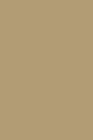

In [ ]:
from typing import List, Tuple, Union
import numpy as np
from PIL import Image
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import os, glob, random, torch

def mean_rgb_single_image(img_path: str) -> Image.Image:
    """
    Convert a single image into its mean RGB color (deterministic based on its first pixel).
    
    Args:
        img_path: Path to the image file.

    Returns:
        PIL.Image: Image where every pixel is the mean RGB color of the original.
    """
    img = Image.open(img_path).convert("RGB")
    arr = np.array(img)

    # Compute mean RGB color (float then cast to uint8)
    mean_color = arr.reshape(-1, 3).mean(axis=0)
    mean_color = np.clip(mean_color, 0, 255).astype(np.uint8)

    # Create constant color image
    h, w, _ = arr.shape
    mean_img = np.ones((h, w, 3), dtype=np.uint8) * mean_color

    return Image.fromarray(mean_img)

def mean_rgb_batch_parallel(
    image_paths: List[str],
    batch_size: int = 4,
    max_workers: int = 4
) -> List[Image.Image]:
    """
    Convert a list of images to their mean RGB images, processed in parallel.
    Deterministic per image — independent of order, threads, or kernel restarts.
    """
    mean_images = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Computing Mean RGB"):
        batch_paths = image_paths[i:i + batch_size]

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            results = list(executor.map(mean_rgb_single_image, batch_paths))

        mean_images.extend(results)

    return mean_images

# ---------------- Example usage ----------------

directory = r"C:\\MastersRepos\\ARI5902-Research-Topics-in-AI\\LAION-5B Testing\\clip_embeddings_resumable_symlink\\downloaded_images\\0000"
extensions = tuple(ext.lower() for ext in (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"))
image_paths = glob.glob(os.path.join(directory, "**", "*.*"), recursive=True)
image_paths = [p for p in image_paths if p.lower().endswith(extensions)][:1000]

mean_rgb_imgs = mean_rgb_batch_parallel(
    image_paths, batch_size=8, max_workers=8
)

### Object Detection

In [ ]:
# !python -m pip install git+https://github.com/facebookresearch/detectron2.git

In [8]:
import torch
import detectron2
print(torch.__version__)
print(detectron2.__version__)


2.4.1+cu124
0.6


In [10]:
import urllib.request
import os

url = "https://dl.fbaipublicfiles.com/detectron2/ViTDet/LVIS/cascade_mask_rcnn_vitdet_h/332552778/model_final_11bbb7.pkl"
dst = "VitDet_huge_LVIS.pkl"
urllib.request.urlretrieve(url, dst)
print("Downloaded model to", dst)

Downloaded model to VitDet_huge_LVIS.pkl


In [16]:
# !git clone https://github.com/facebookresearch/detectron2.git

In [3]:
from detectron2.config import LazyConfig, instantiate
from detectron2.checkpoint import DetectionCheckpointer

cfg = LazyConfig.load(r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\detectron2\projects\ViTDet\configs\LVIS\cascade_mask_rcnn_vitdet_h_100ep.py")
cfg.train.init_checkpoint = r"VitDet_huge_LVIS.pkl"

model = instantiate(cfg.model)
DetectionCheckpointer(model).load(cfg.train.init_checkpoint)
model.eval().to("cuda")

GeneralizedRCNN(
  (backbone): SimpleFeaturePyramid(
    (simfp_2): Sequential(
      (0): ConvTranspose2d(1280, 640, kernel_size=(2, 2), stride=(2, 2))
      (1): LayerNorm()
      (2): GELU(approximate='none')
      (3): ConvTranspose2d(640, 320, kernel_size=(2, 2), stride=(2, 2))
      (4): Conv2d(
        320, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
        (norm): LayerNorm()
      )
      (5): Conv2d(
        256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
        (norm): LayerNorm()
      )
    )
    (simfp_3): Sequential(
      (0): ConvTranspose2d(1280, 640, kernel_size=(2, 2), stride=(2, 2))
      (1): Conv2d(
        640, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
        (norm): LayerNorm()
      )
      (2): Conv2d(
        256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
        (norm): LayerNorm()
      )
    )
    (simfp_4): Sequential(
      (0): Conv2d(
        1280, 256, kernel_size=(1, 1), stride=(1, 

c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv - Copy - Copy\lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


(71, 4) (71,) (71,)


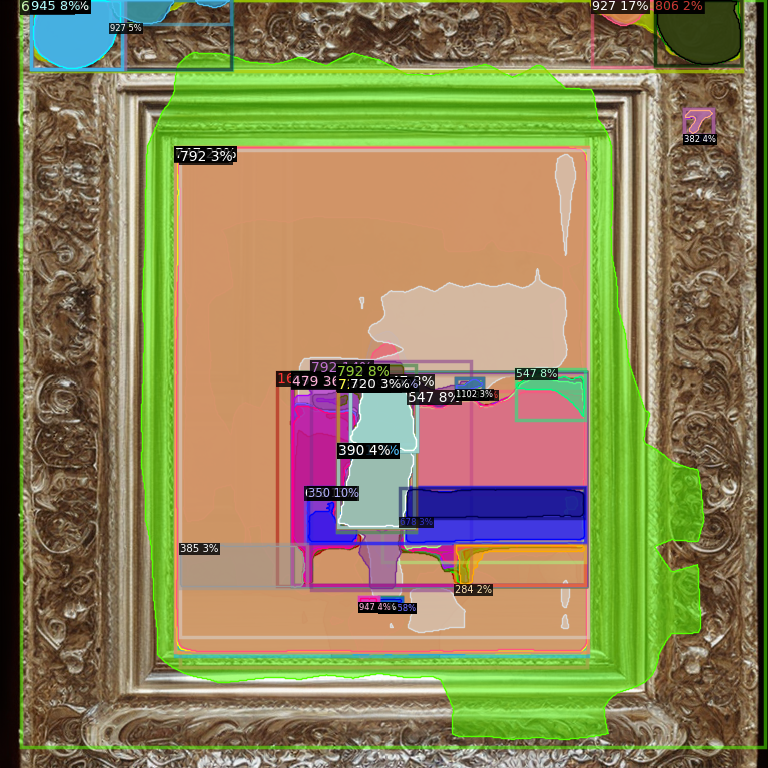

In [19]:
import torch
import cv2
from PIL import Image
import numpy as np
from detectron2.data.transforms import ResizeShortestEdge

# optional: for visualization
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog

img_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"
img = cv2.imread(img_path)[:, :, ::-1]  # BGR -> RGB
height, width = img.shape[:2]

# Resize using same transform as used in training
transform = ResizeShortestEdge(short_edge_length=1024, max_size=1024)
tf = transform.get_transform(img)
img_tensor = torch.tensor(tf.apply_image(img)).permute(2, 0, 1).unsqueeze(0).float().cuda()

model.eval()
with torch.no_grad():
    inputs = [{"image": img_tensor[0], "height": height, "width": width}]
    outputs = model(inputs)

# outputs is a list of dicts (one per image)
pred_instances = outputs[0]["instances"]
pred_boxes = pred_instances.pred_boxes.tensor.cpu().numpy()
pred_classes = pred_instances.pred_classes.cpu().numpy()
pred_scores = pred_instances.scores.cpu().numpy()

print(pred_boxes.shape, pred_classes.shape, pred_scores.shape)

metadata = MetadataCatalog.get("lvis_v1")  # LVIS metadata
v = Visualizer(img, metadata=metadata, instance_mode=ColorMode.IMAGE)
out = v.draw_instance_predictions(pred_instances.to("cpu"))
Image.fromarray(out.get_image())


mirror: 0.89
skirt: 0.89
bed: 0.85
dress: 0.73
flip-flop_(sandal): 0.66
short_pants: 0.60
flip-flop_(sandal): 0.58


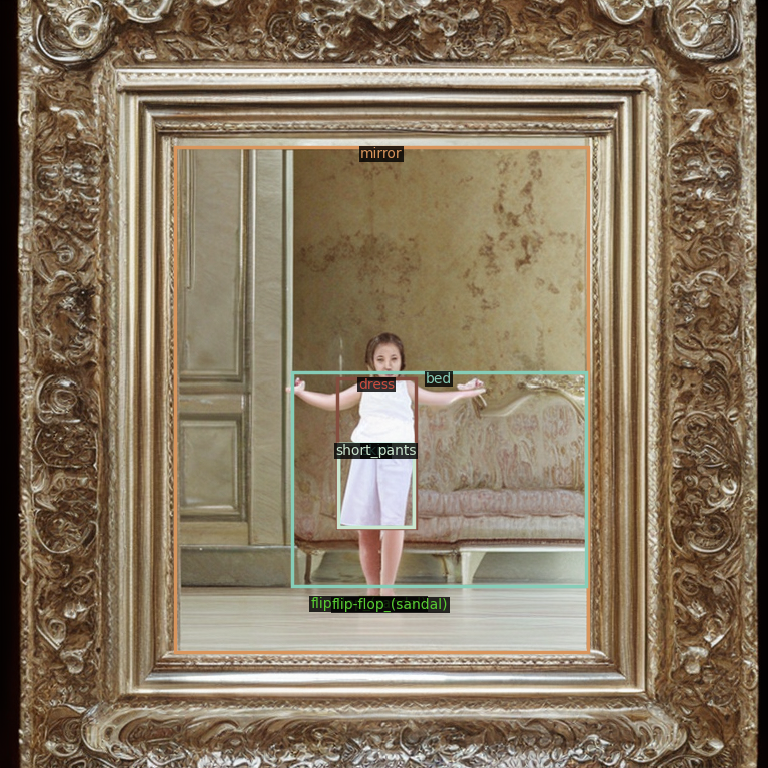

In [5]:
import torch
import cv2
from PIL import Image
import numpy as np
from detectron2.data.transforms import ResizeShortestEdge
from detectron2.utils.visualizer import Visualizer, ColorMode
import json

# --- Load image ---
img_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"
img = cv2.imread(img_path)[:, :, ::-1]  # BGR -> RGB
height, width = img.shape[:2]

# --- Resize as used in training ---
transform = ResizeShortestEdge(short_edge_length=1024, max_size=1024)
tf = transform.get_transform(img)
img_tensor = torch.tensor(tf.apply_image(img)).permute(2, 0, 1).unsqueeze(0).float().cuda()

# --- Run model ---
model.eval()
with torch.no_grad():
    inputs = [{"image": img_tensor[0], "height": height, "width": width}]
    outputs = model(inputs)

pred_instances = outputs[0]["instances"]

# --- Set confidence threshold ---
conf_thresh = 0.5
keep = pred_instances.scores > conf_thresh
pred_instances = pred_instances[keep]

# --- Load JSON mapping class names and colors ---
with open("LVIS_color_map.json", "r") as f:
    color_dict = json.load(f)

class_names = list(color_dict.keys())        # class names
class_colors = list(color_dict.values())     # RGB colors

# Map predicted indices to names and colors
pred_classes_names = [class_names[i] for i in pred_instances.pred_classes.cpu().numpy()]
pred_colors = [tuple(class_colors[i]) for i in pred_instances.pred_classes.cpu().numpy()]

# --- Optional: print filtered predictions ---
for name, score in zip(pred_classes_names, pred_instances.scores.cpu().numpy()):
    print(f"{name}: {score:.2f}")

# --- Visualize ---
v = Visualizer(img, instance_mode=ColorMode.IMAGE)
for bbox, cls_name, color in zip(pred_instances.pred_boxes.tensor.cpu().numpy(),
                                 pred_classes_names,
                                 pred_colors):
    # Normalize RGB to 0-1 for Visualizer
    norm_color = [c / 255 for c in color]
    v.draw_box(bbox, alpha=1, edge_color=norm_color)
    x_center = (bbox[0] + bbox[2]) / 2
    y = min(bbox[1], bbox[3])
    v.draw_text(cls_name, (x_center, y), color=norm_color)

Image.fromarray(v.get_output().get_image())


### Image Caption

In [2]:
import torch
from PIL import Image
from transformers import LlavaProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

model_id = "llava-hf/llava-1.5-7b-hf"
processor = LlavaProcessor.from_pretrained(model_id, use_fast=True)
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="cuda"
)

def generate_caption(image_path, caption_type="short"):
    image = Image.open(image_path).convert("RGB")

    if caption_type == "short":
        prompt = "USER: <image>\nDescribe this image in one sentence.\nASSISTANT:"
        max_tokens = 50
    else:
        prompt = "USER: <image>\nDescribe this image in one paragraph.\nASSISTANT:"
        max_tokens = 150

    inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_tokens)
        caption = processor.decode(output[0], skip_special_tokens=True)
        caption = caption.split("ASSISTANT:")[-1].strip()

    return caption

# Example usage
img_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"
short_caption = generate_caption(img_path, caption_type="short")
long_caption = generate_caption(img_path, caption_type="long")

print("Short caption:", short_caption)
print("Long caption:", long_caption)


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Short caption: A girl is standing in front of a mirror.
Long caption: The image features a young girl standing in a room, possibly a living room, with her arms outstretched. She is positioned in front of a mirror, which reflects her pose. The room also contains a couch and a chair, adding to the cozy atmosphere. The girl appears to be enjoying her time in the room, possibly engaging in a playful activity or simply posing for the camera.


### VAE

In [18]:
import torch
print(torch.__version__)      # e.g., 2.6.0+cu124
print(torch.version.cuda)     # e.g., 12.4

2.6.0+cu124
12.4


In [6]:
import torchvision
print(torchvision.__version__)

RuntimeError: operator torchvision::nms does not exist

In [6]:
pip show taming-transformers

Name: taming-transformers
Version: 0.0.1
Summary: Taming Transformers for High-Resolution Image Synthesis
Home-page: UNKNOWN
Author: 
Author-email: 
License: UNKNOWN
Location: c:\mastersrepos\ari5902-research-topics-in-ai\laion-5b testing\.venv-copy-copy\lib\site-packages
Requires: numpy, torch, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [7]:
from taming.models.vqgan import VQModel, GumbelVQ


ModuleNotFoundError: No module named 'taming'

In [2]:
import torch, torchvision, taming_transformers, numpy, PIL, cv2, omegaconf
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('taming-transformers:', taming_transformers.__version__)
print('numpy:', numpy.__version__)
print('PIL:', PIL.__version__)
print('opencv:', cv2.__version__)
print('omegaconf:', omegaconf.__version__)

RuntimeError: operator torchvision::nms does not exist

In [5]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124

In [2]:
pip install --no-deps --force-reinstall git+https://github.com/CompVis/taming-transformers.git@master#egg=taming-transformers

  Cloning https://github.com/CompVis/taming-transformers.git (to revision master) to c:\users\user\appdata\local\temp\pip-install-86778ihl\taming-transformers_b795b27821d44410bbcf6093ad8608bb
  Resolved https://github.com/CompVis/taming-transformers.git to commit 3ba01b241669f5ade541ce990f7650a3b8f65318
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for taming-transformers: filename=taming_transformers-0.0.1-py3-none-any.whl size=2042 sha256=a5d3c9b2729be573ab3861002dfaaea7ceec574592d068ce1cf50ac3587ee23f
  Stored in directory: C:\Users\User\AppData\Local\Temp\pip-ephem-wheel-cache-9oy1hf7q\wheels\12\09\b8\9428139e2e6d798056371e0de0df5157d521c37c949fc6e6ce
Successfully built taming-transformers
  Attempting uninstall: taming-transformers
    Found existing installation: taming-transformers 0.0.1
    Uninstalling taming-transformers-0.0.1:
      Successfully uninstalled taming-transformers-0.0.1
Note: you may need to

  Running command git clone --filter=blob:none --quiet https://github.com/CompVis/taming-transformers.git 'C:\Users\User\AppData\Local\Temp\pip-install-86778ihl\taming-transformers_b795b27821d44410bbcf6093ad8608bb'
  DEPRECATION: Building 'taming-transformers' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'taming-transformers'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip list

Package                   Version
------------------------- ------------------
absl-py                   2.3.1
accelerate                1.10.1
addict                    2.4.0
aiofiles                  24.1.0
aiohappyeyeballs          2.4.3
aiohttp                   3.10.10
aiosignal                 1.3.1
albucore                  0.0.17
albumentations            1.4.18
aliyun-python-sdk-core    2.16.0
aliyun-python-sdk-kms     2.16.5
all-clip                  1.2.0
aniso8601                 9.0.1
annotated-types           0.7.0
antlr4-python3-runtime    4.9.3
appdirs                   1.4.4
asttokens                 2.4.1
async-timeout             4.0.3
attrs                     24.2.0
autofaiss                 2.17.0
bitsandbytes              0.48.1
black                     25.9.0
blinker                   1.8.2
braceexpand               0.1.7
certifi                   2024.8.30
cffi                      2.0.0
cfgv                      3.4.0
charset-normalizer        3.4.0
click    

In [2]:
import torch
print("torch:", torch.__version__)

import torchvision
print("torchvision:", torchvision.__version__)

import taming
print("taming-transformers:", taming.__version__)

torch: 2.6.0+cu124
torchvision: 0.21.0+cu124


ModuleNotFoundError: No module named 'taming'

In [ ]:
from taming.models.vqgan import VQModel
print("taming-transformers import worked")

ModuleNotFoundError: No module named 'taming'

In [1]:
pip install pytorch-lightning


   ---------------------------------------- 0.0/832.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/832.4 kB ? eta -:--:--
   ------------ --------------------------- 262.1/832.4 kB ? eta -:--:--
   ------------------------- -------------- 524.3/832.4 kB 1.2 MB/s eta 0:00:01
   ------------------------------------- -- 786.4/832.4 kB 1.2 MB/s eta 0:00:01
   ------------------------------------- -- 786.4/832.4 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 832.4/832.4 kB 618.5 kB/s  0:00:01
   ---------------------------------------- 0.0/983.2 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/983.2 kB ? eta -:--:--
   --------------------- ------------------ 524.3/983.2 kB 1.5 MB/s eta 0:00:01
   ------------------------------- -------- 786.4/983.2 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 983.2/983.2 kB 1.5 MB/s  0:00:00

   ---------------------------------------- 0/3 [lightning-utilities]
   ----------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# pip install "C:\Users\User\Downloads\triton-3.0.0-cp310-cp310-win_amd64.whl"

In [4]:
pip uninstall xformers -y

Found existing installation: xformers 0.0.28.post1Note: you may need to restart the kernel to use updated packages.

Uninstalling xformers-0.0.28.post1:
  Successfully uninstalled xformers-0.0.28.post1


In [1]:
import torch
print(torch.__version__)

2.6.0+cu124


In [2]:
pip install -U xformers --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
INFO: pip is looking at multiple versions of xformers to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/167.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/167.7 MB 5.6 MB/s eta 0:00:30
    --------------------------------------- 3.1/167.7 MB 10.9 MB/s eta 0:00:16
   -- ------------------------------------- 9.4/167.7 MB 19.6 MB/s eta 0:00:09
   -- ------------------------------------- 11.8/167.7 MB 18.5 MB/s eta 0:00:09
   --- ------------------------------------ 14.2/167.7 MB 15.9 MB/s eta 0:00:10
   ---- ----------------------------------- 19.1/167.7 MB 18.3 MB/s eta 0:00:09
   ----- ---------------------------------- 23.3/167.7 MB 18.0 MB/s eta 0:00:09
   ------ --------------------------------- 27.3/167.7 MB 18.2 MB/s eta 0:00:08
   ------ --------------------------------- 28.0/167.7 MB 17.3 MB/s eta 0:00:09
   ------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install xformers --no-cache-dir

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/100.2 MB 2.0 MB/s eta 0:00:51
   ---------------------------------------- 1.0/100.2 MB 1.7 MB/s eta 0:00:58
    --------------------------------------- 1.3/100.2 MB 1.5 MB/s eta 0:01:07
    --------------------------------------- 1.3/100.2 MB 1.5 MB/s eta 0:01:07
    --------------------------------------- 1.6/100.2 MB 1.4 MB/s eta 0:01:12
    --------------------------------------- 1.8/100.2 MB 1.3 MB/s eta 0:01:17
    --------------------------------------- 2.1/100.2 MB 1.3 MB/s eta 0:01:16
    --------------------------------------- 2.4/100.2 MB 1.3 MB/s eta 0:01:15
   - -------------------------------------- 2.9/100.2 MB 1.4 MB/s eta 0:01:12
   - -------------------------------------- 3.1/100.2 MB 1.3 MB/s eta 0:01:13
   - -------------------------------------- 3.4/100.2 MB 1.3 MB/s eta 0:01:13


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
clip-retrieval 2.44.0 requires numpy<2,>=1.19.5, but you have numpy 2.2.6 which is incompatible.
clip-retrieval 2.44.0 requires pyarrow<15,>=6.0.1, but you have pyarrow 21.0.0 which is incompatible.
clip-retrieval 2.44.0 requires scipy<1.12, but you have scipy 1.15.3 which is incompatible.
pyiqa 0.1.14.1 requires accelerate<=1.1.0, but you have accelerate 1.10.1 which is incompatible.
pyiqa 0.1.14.1 requires transformers==4.37.2, but you have transformers 4.57.1 which is incompatible.
torchaudio 2.6.0+cu124 requires torch==2.6.0+cu124, but you have torch 2.8.0 which is incompatible.
torchvision 0.21.0+cu124 requires torch==2.6.0+cu124, but you have torch 2.8.0 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import torch
from PIL import Image
from torchvision import transforms
from diffusers import AutoencoderKL

# === Step 1: Load the pre-trained VAE ===
# This is the same VAE used in Stable Diffusion 1.5
vae = AutoencoderKL.from_pretrained(
    "stabilityai/sd-vae-ft-mse", 
    torch_dtype=torch.float16
).to("cuda")

vae.eval()

# === Step 2: Load and preprocess image ===
image_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"
image = Image.open(image_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((512, 512), interpolation=Image.BICUBIC),       # SD VAE expects 512×512 inputs
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])   # scale to [-1, 1]
])

img_tensor = transform(image).unsqueeze(0).to("cuda", dtype=torch.float16)

# === Step 3: Encode → Decode ===
with torch.no_grad():
    latent = vae.encode(img_tensor).latent_dist.sample() * 0.18215  # scaling factor used in SD
    recon = vae.decode(latent / 0.18215).sample  # reconstruct back
    recon = (recon.clamp(-1, 1) + 1) / 2  # back to [0,1]

# === Step 4: Save reconstructed image ===
recon_image = transforms.ToPILImage()(recon.squeeze().cpu())
# print(f"✅ Reconstructed image saved at: {save_path}")

### Canny Edge

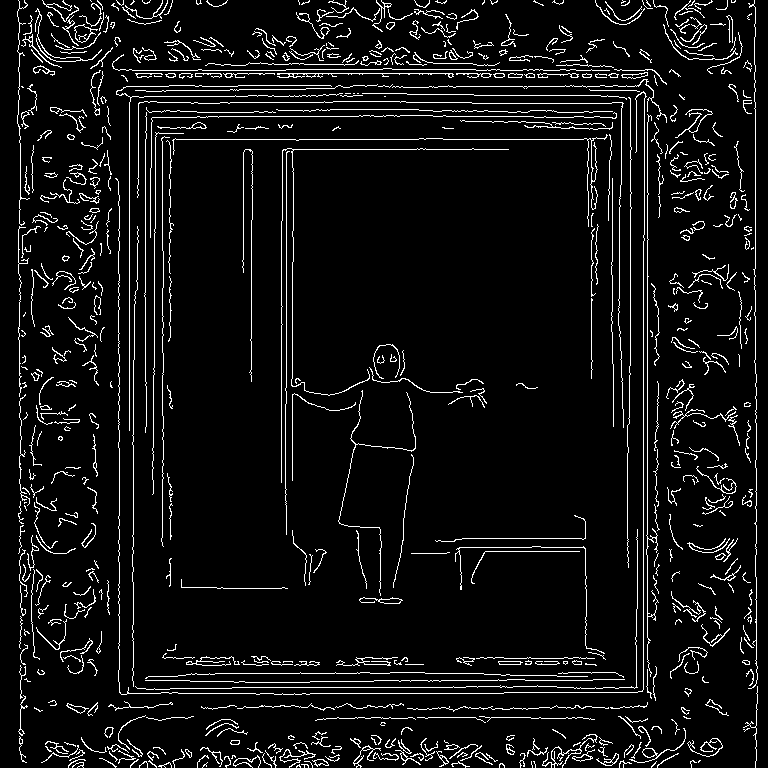

In [14]:
import cv2
from PIL import Image
import numpy as np

# Load image
image_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"
image = cv2.imread(image_path, cv2.IMREAD_COLOR)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # convert to grayscale

# Apply Gaussian blur to reduce noise
blur = cv2.GaussianBlur(gray, (5, 5), 1.4)

# Apply Canny edge detection
edges = cv2.Canny(blur, threshold1=100, threshold2=200)

# Convert edges to PIL image for visualization
edges_pil = Image.fromarray(edges)
edges_pil

### SAM

In [ ]:
# https://github.com/facebookresearch/segment-anything - checkpoint downlaoded from here
# !pip install git+https://github.com/facebookresearch/segment-anything.git

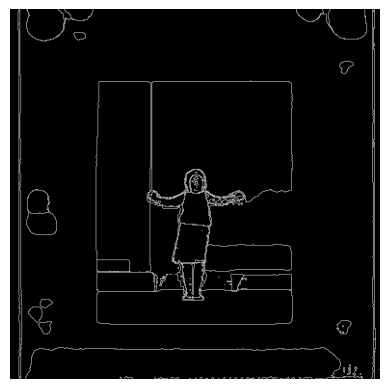

✅ Binary contour mask saved to: sam_binary_contour.png


In [1]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
import torch
from PIL import Image
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt

# --- Load SAM model ---
model_type = "vit_l"  # ViT-Large
sam_checkpoint = r"sam_vit_l_0b3195.pth"  # update this path
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to("cuda")

# --- Prepare mask generator ---
mask_generator = SamAutomaticMaskGenerator(sam)

# --- Load image ---
image_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"
image_np = np.array(Image.open(image_path).convert("RGB"))

# --- Generate masks ---
masks = mask_generator.generate(image_np)

# --- Create binary contour mask (black background, white edges) ---
contour_mask = np.zeros(image_np.shape[:2], dtype=np.uint8)

for mask in masks:
    segmentation = mask["segmentation"]
    contours = measure.find_contours(segmentation, 0.5)
    for contour in contours:
        contour = np.round(contour).astype(int)
        contour_mask[contour[:, 0], contour[:, 1]] = 255

# --- Save and visualize ---
output_path = "sam_binary_contour.png"
Image.fromarray(contour_mask).save(output_path)

plt.imshow(contour_mask, cmap="gray")
plt.axis("off")
plt.show()

print(f"✅ Binary contour mask saved to: {output_path}")

### Depth

In [10]:
# https://github.com/DepthAnything/Depth-Anything-V2?tab=readme-ov-file

In [5]:
from transformers import pipeline
from PIL import Image
import numpy as np
import os # Import os for better file handling

# Load pipeline
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Large-hf")

# Directory and image path (assuming you're using the same image twice for testing)
image_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"

# Load images into a list
image = Image.open(image_path).convert("RGB")
image_2 = Image.open(image_path).convert("RGB")
imgs = [image, image_2] # Your batch input

# Inference (Batch Call)
# 'results' is a list of dictionaries, e.g., [{'depth': ...}, {'depth': ...}]
results = pipe(imgs) 

# --- Post-processing and Saving ---
# Iterate over the list of results
for i, result in enumerate(results):
    # Get the depth map PIL Image from the dictionary
    depth_pil = result["depth"] # This is now correct for a single result item
    
    # Convert to NumPy array
    depth_np = np.array(depth_pil).astype(np.float32)

    # Normalize to 0-255
    depth_np = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min()) * 255.0
    depth_np = depth_np.astype(np.uint8)

    # Save as image
    depth_pil_out = Image.fromarray(depth_np)
    
    # Example: Save with a unique name
    output_path = f"depth_map_output_{i+1}.png"
    depth_pil_out.save(output_path)
    print(f"Saved depth map for image {i+1} to {output_path}")
    
# depth_pil_out # This will display the last saved image if run in a notebook

Device set to use cuda:0


In [6]:
from transformers import pipeline
from PIL import Image
import numpy as np

# Load pipeline
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Large-hf")

# Load image
image_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"
image = Image.open(image_path).convert("RGB")
image_2 = Image.open(image_path).convert("RGB")

imgs = [image, image_2]

# Inference
# depth_pil = pipe(image)["depth"]  # this is a PIL Image
depth_pil = pipe(imgs)#["depth"]  # this is a PIL Image
# depth_np = np.array(depth_pil).astype(np.float32)  # convert to NumPy array

# # Normalize to 0-255
# depth_np = (depth_np - depth_np.min()) / (depth_np.max() - depth_np.min()) * 255.0
# depth_np = depth_np.astype(np.uint8)

# # Save as image
# depth_pil_out = Image.fromarray(depth_np)
# depth_pil_out

Device set to use cuda:0


### High & Low Filter

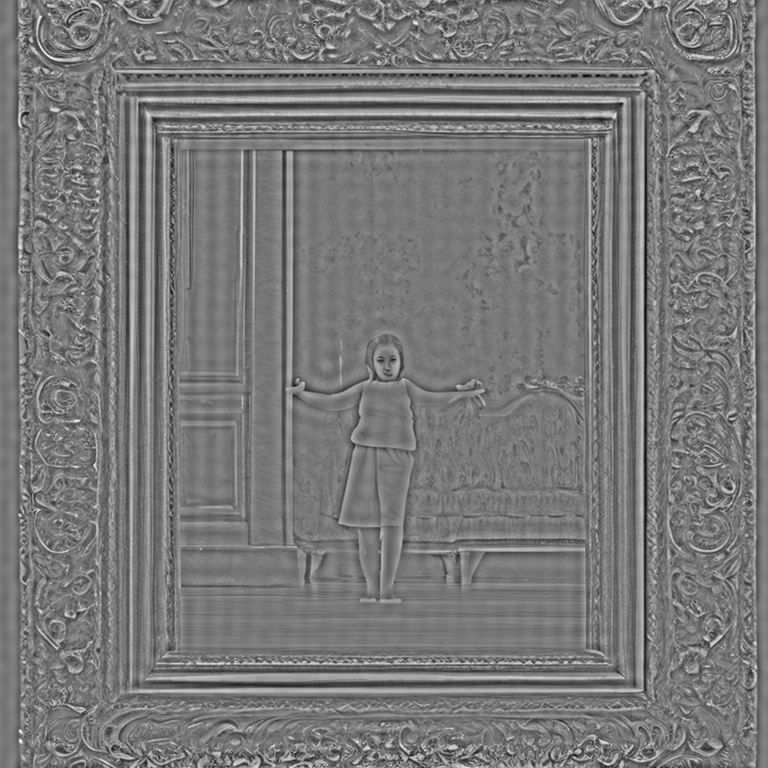

In [ ]:
import numpy as np
from PIL import Image
import cv2

def high_low_pass_filter(image_path, radius=40):
    """
    Apply ideal low-pass and high-pass filters on a single image.
    :param image_path: path to RGB image
    :param radius: cutoff radius in frequency domain
    :return: (low_pass_img, high_pass_img) as uint8 grayscale images
    """
    # Load and convert to grayscale
    img = Image.open(image_path).convert("L")
    img_np = np.array(img, dtype=np.float32)

    # 2D FFT
    f = np.fft.fft2(img_np)
    fshift = np.fft.fftshift(f)

    rows, cols = img_np.shape
    crow, ccol = rows // 2, cols // 2

    # Create masks
    mask_low = np.zeros_like(img_np)
    mask_high = np.ones_like(img_np)

    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((x - ccol)**2 + (y - crow)**2)

    mask_low[distance <= radius] = 1        # low-pass: keep low frequencies
    mask_high[distance <= radius] = 0       # high-pass: remove low frequencies

    # Apply masks
    fshift_low = fshift * mask_low
    fshift_high = fshift * mask_high

    # Inverse FFT
    img_low = np.fft.ifft2(np.fft.ifftshift(fshift_low)).real
    img_high = np.fft.ifft2(np.fft.ifftshift(fshift_high)).real

    # Normalize to 0-255
    img_low = cv2.normalize(img_low, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img_high = cv2.normalize(img_high, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    return img_low, img_high

# Example usage
image_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images\a girl_1.png"
low_pass, high_pass = high_low_pass_filter(image_path)

# Save or show
Image.fromarray(low_pass)
Image.fromarray(high_pass)

# Loading the Images via Dataloader

In [1]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import numpy as np
import torch
import os

# ---------------- Dataset ----------------
class ImageDataset(Dataset):
    def __init__(self, image_dir: str, extensions=(".jpg", ".jpeg", ".png"), transform=None):
        self.image_paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(extensions)
        ]
        self.transform = transform or T.Compose([
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")
        return img, path

# ---------------- Collate Function ----------------
def collate_images(batch):
    imgs, paths = zip(*batch)
    return list(imgs), list(paths)

# ---------------- Prefetching Loader ----------------
class PrefetchLoader:
    """Wrap a DataLoader to prefetch the next batch to GPU asynchronously."""
    def __init__(self, loader, device):
        self.loader = iter(loader)
        self.device = device
        self.stream = torch.cuda.Stream() if device == "cuda" else None
        self.next_batch = None
        self._prefetch()

    def _prefetch(self):
        try:
            imgs, paths = next(self.loader)
        except StopIteration:
            self.next_batch = None
            return

        if self.device == "cuda":
            with torch.cuda.stream(self.stream):
                # Convert to tensor and move to GPU asynchronously
                self.next_batch = (
                    [torch.tensor(np.array(img)).permute(2,0,1).float()/255.0
                    for img in imgs],
                    paths
                )
        else:
            self.next_batch = (
                [torch.tensor(np.array(img)).permute(2,0,1).float()/255.0
                for img in imgs],
                paths
            )

    def __iter__(self):
        return self

    def __next__(self):
        if self.next_batch is None:
            raise StopIteration
        batch = self.next_batch
        self._prefetch()
        return batch
    
# ---------------- DataLoader setup ----------------
def get_image_loader(image_dir: str, batch_size=4, num_workers=4, device='cpu'):
    dataset = ImageDataset(image_dir)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=False,
        collate_fn=collate_images,
        pin_memory=True
    )
    prefetch_loader = PrefetchLoader(loader, device=device)
    return prefetch_loader, len(dataset)

In [ ]:
# image_dir = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images"
# device = "cuda" if torch.cuda.is_available() else "cpu"
# loader, dataset_size = get_image_loader(image_dir, batch_size=4, num_workers=0, device=device)

## Semantic Segmentation

In [ ]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
from tqdm import tqdm

# ---------------- Main Processing Function ----------------
def segment_images(image_dir, batch_size=4, num_workers=4):

    # ADE20K palette
    ade_palette = np.array([
        (120, 120, 120), (180, 120, 120), (6, 230, 230), (80, 50, 50),
        (4, 200, 3), (120, 120, 80), (140, 140, 140), (204, 5, 255),
        (230, 230, 230), (4, 250, 7), (224, 5, 255), (235, 255, 7),
        (150, 5, 61), (120, 120, 70), (8, 255, 51), (255, 6, 82),
        (143, 255, 140), (204, 255, 4), (255, 51, 7), (204, 70, 3),
        (0, 102, 200), (61, 230, 250), (255, 6, 51), (11, 102, 255),
        (255, 7, 71), (255, 9, 224), (9, 7, 230), (220, 220, 220),
        (255, 9, 92), (112, 9, 255), (8, 255, 214), (7, 255, 224),
        (255, 184, 6), (10, 255, 71), (255, 41, 10), (7, 255, 255),
        (224, 255, 8), (102, 8, 255), (255, 61, 6), (255, 194, 7),
        (255, 122, 8), (0, 255, 20), (255, 8, 41), (255, 5, 153),
        (6, 51, 255), (235, 12, 255), (160, 150, 20), (0, 163, 255),
        (140, 140, 140), (250, 10, 15), (20, 255, 0), (31, 255, 0),
        (255, 31, 0), (255, 224, 0), (153, 255, 0), (0, 0, 255),
        (255, 71, 0), (0, 235, 255), (0, 173, 255), (31, 0, 255),
        (11, 200, 200), (255, 82, 0), (0, 255, 245), (0, 61, 255),
        (0, 255, 112), (0, 255, 133), (255, 0, 0), (255, 163, 0),
        (255, 102, 0), (194, 255, 0), (0, 143, 255), (51, 255, 0),
        (0, 82, 255), (0, 255, 41), (0, 255, 173), (10, 0, 255),
        (173, 255, 0), (0, 255, 153), (255, 92, 0), (255, 0, 255),
        (255, 0, 245), (255, 0, 102), (255, 173, 0), (255, 0, 20),
        (255, 184, 184), (0, 31, 255), (0, 255, 61), (0, 71, 255),
        (255, 0, 204), (0, 255, 194), (0, 255, 82), (0, 10, 255),
        (0, 112, 255), (51, 0, 255), (0, 194, 255), (0, 122, 255),
        (0, 255, 163), (255, 153, 0), (0, 255, 10), (255, 112, 0),
        (143, 255, 0), (82, 0, 255), (163, 255, 0), (255, 235, 0),
        (8, 184, 170), (133, 0, 255), (0, 255, 92), (184, 0, 255),
        (255, 0, 31), (0, 184, 255), (0, 214, 255), (255, 0, 112),
        (92, 255, 0), (0, 224, 255), (112, 224, 255), (70, 184, 160),
        (163, 0, 255), (153, 0, 255), (71, 255, 0), (255, 0, 163),
        (255, 204, 0), (255, 0, 143), (0, 255, 235), (133, 255, 0),
        (255, 0, 235), (245, 0, 255), (255, 0, 122), (255, 245, 0),
        (10, 190, 212), (214, 255, 0), (0, 204, 255), (20, 0, 255),
        (255, 255, 0), (0, 153, 255), (0, 41, 255), (0, 255, 204),
        (41, 0, 255), (41, 255, 0), (173, 0, 255), (0, 245, 255),
        (71, 0, 255), (122, 0, 255), (0, 255, 184), (0, 92, 255),
        (184, 255, 0), (0, 133, 255), (255, 214, 0), (25, 194, 194),
        (102, 255, 0), (92, 0, 255)
    ], dtype=np.uint8)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model + processor
    model = Mask2FormerForUniversalSegmentation.from_pretrained(
        "facebook/mask2former-swin-large-ade-semantic"
    ).to(device).eval()
    processor = AutoImageProcessor.from_pretrained(
        "facebook/mask2former-swin-large-ade-semantic",
        use_fast=True
    )

    prefetch_loader, dataset_size = get_image_loader(image_dir, batch_size=batch_size, num_workers=num_workers, device=device)

    segmented_images = []

    for batch_imgs, batch_paths in tqdm(prefetch_loader, total=(dataset_size+batch_size-1)//batch_size):
        # batch_imgs already on GPU if device=='cuda', else CPU tensors
        batch_imgs_list = [Image.fromarray((img.permute(1,2,0).cpu().numpy()*255).astype(np.uint8)) 
                           for img in batch_imgs]

        target_sizes = [(img.height, img.width) for img in batch_imgs_list]

        # Run Mask2Former inference
        with torch.no_grad():
            outputs = model(**processor(images=batch_imgs_list, return_tensors="pt").to(device))

        # Postprocess semantic segmentation
        seg_maps = processor.post_process_semantic_segmentation(outputs, target_sizes=target_sizes)

        # Apply ADE20K palette
        for seg_map in seg_maps:
            seg_arr = seg_map.cpu().numpy() % len(ade_palette)
            seg_pil = Image.fromarray(ade_palette[seg_arr])
            segmented_images.append(seg_pil)

    return segmented_images, batch_paths

# ---------------- Example Usage ----------------
# Example: image_paths = list of paths to images
image_dir = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images"
segmented_images, segmented_image_original_paths = segment_images(image_dir, batch_size=4, num_workers=0)

Skipping import of cpp extensions due to incompatible torch version 2.6.0+cu124 for torchao version 0.14.0         Please see GitHub issue #2919 for more info
 16%|█▌        | 401/2500 [11:21<1:23:28,  2.39s/it]

## Object Detection

- Takes to long to execute
- Output Bounding Boxes Dont Seem To Align With Image Size

- Reference this for the original solution: https://github.com/boyazeng/understand_bias/blob/main/transformations/object_det/transform.py

(Maybe leave it for the weekend since it seems to be a bit tedious to resolve)

In [1]:
import torch
import cv2
from PIL import Image
import numpy as np
import json
from tqdm import tqdm
from detectron2.config import LazyConfig, instantiate
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.data.transforms import ResizeShortestEdge
from detectron2.utils.visualizer import Visualizer, ColorMode

def object_detection_images(image_dir, model_path, checkpoint_path, color_json, batch_size=4, num_workers=4):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- Load Detectron2 model ---
    cfg = LazyConfig.load(model_path)
    cfg.train.init_checkpoint = checkpoint_path

    # Patch np.float_ for NumPy 2.0 compatibility
    np.float_ = np.float = np.float64
    np.complex_ = np.complex = np.complex128

    model = instantiate(cfg.model)
    DetectionCheckpointer(model).load(cfg.train.init_checkpoint)
    model.eval().to(device)

    # --- Load class-color mapping ---
    with open(color_json, "r") as f:
        color_dict = json.load(f)
    class_names = list(color_dict.keys())
    class_colors = list(color_dict.values())

    # --- Prepare PrefetchLoader ---
    prefetch_loader, dataset_size = get_image_loader(
        image_dir, batch_size=batch_size, num_workers=num_workers, device=device
    )

    object_detection_images = []

    # --- Define resizing transform (as in training) ---
    transform = ResizeShortestEdge(short_edge_length=1024, max_size=1024)

    # --- Process batches ---
    for batch_imgs, batch_paths in tqdm(prefetch_loader, total=(dataset_size + batch_size - 1) // batch_size):

        # batch_imgs: already on GPU if device=='cuda'
        processed_images = []

        for img_tensor in batch_imgs:
            # Convert tensor -> HWC uint8 image
            img = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            height, width = img.shape[:2]

            # Resize using Detectron2's transform
            tf = transform.get_transform(img)
            resized = tf.apply_image(img)
            img_tensor_resized = torch.tensor(resized).permute(2, 0, 1).float().to(device)

            # Run object detection
            with torch.no_grad():
                inputs = [{"image": img_tensor_resized, "height": height, "width": width}]
                outputs = model(inputs)

            pred_instances = outputs[0]["instances"]

            # Filter by confidence threshold
            conf_thresh = 0.5
            keep = pred_instances.scores > conf_thresh
            pred_instances = pred_instances[keep]

            # Map predicted classes to names and colors
            pred_classes_names = [class_names[i] for i in pred_instances.pred_classes.cpu().numpy()]
            pred_colors = [tuple(class_colors[i]) for i in pred_instances.pred_classes.cpu().numpy()]

            # Visualize predictions
            v = Visualizer(resized, instance_mode=ColorMode.IMAGE)
            for bbox, cls_name, color in zip(
                pred_instances.pred_boxes.tensor.cpu().numpy(),
                pred_classes_names,
                pred_colors
            ):
                norm_color = [c / 255 for c in color]
                v.draw_box(bbox, alpha=1, edge_color=norm_color)
                x_center = (bbox[0] + bbox[2]) / 2
                y = min(bbox[1], bbox[3])
                v.draw_text(cls_name, (x_center, y), color=norm_color)

            processed_images.append(Image.fromarray(v.get_output().get_image()))

        object_detection_images.extend(processed_images)

    return object_detection_images, batch_paths


image_dir = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images"
model_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\detectron2\projects\ViTDet\configs\LVIS\cascade_mask_rcnn_vitdet_h_100ep.py"
checkpoint_path = r"VitDet_huge_LVIS.pkl"
color_json = r"LVIS_color_map.json"
segmented_images, object_detection_image_original_paths = object_detection_images(image_dir, model_path, checkpoint_path, color_json, batch_size=4, num_workers=0)

NameError: name 'get_image_loader' is not defined

In [ ]:
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from detectron2.data.transforms import ResizeShortestEdge
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.checkpoint import DetectionCheckpointer
from detectron2.config import LazyConfig, instantiate
import json

def object_detection_images_batch(image_dir, model_path, checkpoint_path, color_json, batch_size=4, num_workers=4):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- Load model ---
    cfg = LazyConfig.load(model_path)
    cfg.train.init_checkpoint = checkpoint_path
    np.float_ = np.float = np.float64  # NumPy 2.0 patch
    np.complex_ = np.complex = np.complex128
    model = instantiate(cfg.model)
    DetectionCheckpointer(model).load(cfg.train.init_checkpoint)
    model.eval().to(device)

    # --- Load class-color mapping ---
    with open(color_json, "r") as f:
        color_dict = json.load(f)
    class_names = list(color_dict.keys())
    class_colors = list(color_dict.values())

    # --- Prefetch loader ---
    prefetch_loader, dataset_size = get_image_loader(
        image_dir, batch_size=batch_size, num_workers=num_workers, device=device
    )

    # --- Resizing transform ---
    transform = ResizeShortestEdge(short_edge_length=1024, max_size=1024)

    all_processed_images = []

    for batch_imgs, batch_paths in tqdm(prefetch_loader, total=(dataset_size + batch_size - 1) // batch_size):

        # # batch_imgs is already on device
        # # Convert all images to HWC uint8 for resizing
        # batch_hwc = (batch_imgs.permute(0, 2, 3, 1).cpu().numpy() * 255).astype(np.uint8)

        # # Resize images in batch and keep original sizes
        # resized_tensors = []
        # original_sizes = []
        # for img in batch_hwc:
        #     tf = transform.get_transform(img)
        #     resized = tf.apply_image(img)
        #     resized_tensors.append(torch.tensor(resized).permute(2, 0, 1).float())
        #     original_sizes.append((img.shape[0], img.shape[1]))

        # batch_resized = torch.stack(resized_tensors).to(device)

        # # --- Run model on the batch ---
        # inputs = [{"image": batch_resized[i], "height": original_sizes[i][0], "width": original_sizes[i][1]} 
        #           for i in range(batch_resized.shape[0])]

        inputs = []
        original_images_for_vis = []

        # Iterate over individual C,H,W tensors (already on the correct device)
        for img_tensor in batch_imgs:
            
            # 1. Convert to HWC numpy (0-255 uint8) for Detectron2's transform
            # The tensor is C, H, W, so permute to H, W, C
            img_hwc_np = (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
            original_images_for_vis.append(img_hwc_np) # Save original image for visualization/output
            
            # 2. Apply the ResizeShortestEdge transform
            tf = transform.get_transform(img_hwc_np)
            resized_np = tf.apply_image(img_hwc_np)
            
            # 3. Convert resized image back to C, H, W tensor and keep on device
            resized_tensor = torch.tensor(resized_np, device=img_tensor.device).permute(2, 0, 1).float()
            
            # 4. Build the required input format for Detectron2 (list of dicts)
            inputs.append({
                "image": resized_tensor,
                "height": img_hwc_np.shape[0],
                "width": img_hwc_np.shape[1]
            })

        with torch.no_grad():
            outputs = model(inputs)

        # --- Visualization ---
        for i, output in enumerate(outputs):
            img_resized = original_images_for_vis[i]
            pred_instances = output["instances"]
            conf_thresh = 0.5
            keep = pred_instances.scores > conf_thresh
            pred_instances = pred_instances[keep]

            pred_classes_names = [class_names[j] for j in pred_instances.pred_classes.cpu().numpy()]
            pred_colors = [tuple(class_colors[j]) for j in pred_instances.pred_classes.cpu().numpy()]

            v = Visualizer(img_resized, instance_mode=ColorMode.IMAGE)
            for bbox, cls_name, color in zip(pred_instances.pred_boxes.tensor.cpu().numpy(),
                                             pred_classes_names, pred_colors):
                norm_color = [c / 255 for c in color]
                v.draw_box(bbox, alpha=1, edge_color=norm_color)
                x_center = (bbox[0] + bbox[2]) / 2
                y = min(bbox[1], bbox[3])
                v.draw_text(cls_name, (x_center, y), color=norm_color)

            all_processed_images.append(Image.fromarray(v.get_output().get_image()))

    return all_processed_images, batch_paths

image_dir = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images"
model_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\detectron2\projects\ViTDet\configs\LVIS\cascade_mask_rcnn_vitdet_h_100ep.py"
checkpoint_path = r"VitDet_huge_LVIS.pkl"
color_json = r"LVIS_color_map.json"
segmented_images, object_detection_image_original_paths = object_detection_images_batch(image_dir, model_path, checkpoint_path, color_json, batch_size=4, num_workers=0)

  0%|          | 0/7 [00:00<?, ?it/s]c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv - Copy - Copy\lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
 29%|██▊       | 2/7 [05:12<12:56, 155.36s/it]

In [5]:
import torch, gc, json, numpy as np
from PIL import Image
from tqdm import tqdm
from detectron2.config import LazyConfig, instantiate
from detectron2.checkpoint import DetectionCheckpointer
from torch.utils.data import Dataset, DataLoader
from detectron2.data.transforms import ResizeShortestEdge
from detectron2.utils.visualizer import Visualizer
from torchvision import transforms
import os, glob

# ---- Dataset (adapted from original script) ----
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, transform_size=1024):
        self.paths = glob.glob(os.path.join(image_dir, "*.jpg")) \
                    + glob.glob(os.path.join(image_dir, "*.png")) \
                    + glob.glob(os.path.join(image_dir, "*.jpeg"))
        self.resize_pre = transforms.Resize(500)
        self.transform = ResizeShortestEdge(short_edge_length=transform_size, max_size=transform_size)

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        path = self.paths[i]
        try:
            image = Image.open(path).convert("RGB")
            if min(image.size) > 500:
                image = self.resize_pre(image)
            image = np.array(image, dtype=np.uint8)
            h, w = image.shape[:2]
            t = self.transform.get_transform(image)
            image = t.apply_image(image)
            image = torch.tensor(image).permute(2, 0, 1)
            return {'image': image, 'height': h, 'width': w, 'path': path}
        except Exception as e:
            print(f"Failed {path}: {e}")
            return {'image': None, 'height': 0, 'width': 0, 'path': path}


# ---- Batch object detection ----
def object_detection_images_batch(image_dir, model_path, checkpoint_path, color_json, batch_size=4, num_workers=4):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model
    cfg = LazyConfig.load(model_path)
    cfg.train.init_checkpoint = checkpoint_path
    np.float_ = np.float = np.float64
    np.complex_ = np.complex = np.complex128
    model = instantiate(cfg.model)
    DetectionCheckpointer(model).load(cfg.train.init_checkpoint)
    model.eval().to(device)

    # Load color map
    with open(color_json, "r") as f:
        color_dict = json.load(f)
    class_names = list(color_dict.keys())
    class_colors = list(color_dict.values())

    # Create dataset + loader
    dataset = ImageDataset(image_dir)
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        collate_fn=lambda x: x,
        shuffle=False
    )

    all_results = []
    for batch in tqdm(loader, desc="Detecting"):
        batch = [b for b in batch if b["image"] is not None]
        if not batch:
            continue

        with torch.no_grad():
            outputs = model(batch)  # <-- GPU parallel inference

        for inp, out in zip(batch, outputs):
            img = (inp['image'].permute(1, 2, 0).cpu().numpy()).astype(np.uint8)
            v = Visualizer(np.ones_like(img)*255)  # white background

            pred = out['instances']
            keep = pred.scores > 0.5
            pred = pred[keep]

            for bbox, cls in zip(pred.pred_boxes.tensor.cpu().numpy(), pred.pred_classes.cpu().numpy()):
                color = [c/255 for c in class_colors[cls]]
                v.draw_box(bbox, edge_color=color)
                x_center = (bbox[0] + bbox[2]) / 2
                y = min(bbox[1], bbox[3])
                v.draw_text(class_names[cls], (x_center, y), color=color)

            all_results.append(Image.fromarray(v.get_output().get_image()))

        gc.collect()
        torch.cuda.empty_cache()

    return all_results


image_dir = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images"
model_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\detectron2\projects\ViTDet\configs\LVIS\cascade_mask_rcnn_vitdet_h_100ep.py"
checkpoint_path = r"VitDet_huge_LVIS.pkl"
color_json = r"LVIS_color_map.json"
all_results = object_detection_images_batch(image_dir, model_path, checkpoint_path, color_json, batch_size=4, num_workers=0)

c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv - Copy - Copy\lib\site-packages\detectron2\config\lazy.py:167: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return old_import(name, globals, locals, fromlist=fromlist, level=level)
Detecting:   0%|          | 0/7 [00:00<?, ?it/s]c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv - Copy - Copy\lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Detecting: 100%|██████████| 7/7 [02:50<00:00, 24.38s/it]


In [14]:
import torch, gc, json, numpy as np, cv2
from PIL import Image
from tqdm import tqdm
from detectron2.config import LazyConfig, instantiate
from detectron2.checkpoint import DetectionCheckpointer
from torch.utils.data import Dataset, DataLoader
from detectron2.data.transforms import ResizeShortestEdge
from torchvision import transforms
from concurrent.futures import ThreadPoolExecutor
import os, glob


# ---- Dataset ----
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, transform_size=1024):
        self.paths = glob.glob(os.path.join(image_dir, "*.jpg")) \
                    + glob.glob(os.path.join(image_dir, "*.png")) \
                    + glob.glob(os.path.join(image_dir, "*.jpeg"))
        self.resize_pre = transforms.Resize(500)
        self.transform = ResizeShortestEdge(short_edge_length=transform_size, max_size=transform_size)

    def __len__(self): return len(self.paths)

    def __getitem__(self, i):
        path = self.paths[i]
        try:
            image = Image.open(path).convert("RGB")
            if min(image.size) > 500:
                image = self.resize_pre(image)
            image = np.array(image, dtype=np.uint8)
            h, w = image.shape[:2]
            t = self.transform.get_transform(image)
            image = t.apply_image(image)
            image = torch.tensor(image).permute(2, 0, 1)
            return {'image': image, 'height': h, 'width': w, 'path': path}
        except Exception as e:
            print(f"Failed {path}: {e}")
            return {'image': None, 'height': 0, 'width': 0, 'path': path}


# ---- Parallel OpenCV Visualization Function ----
def draw_detections(inp, out, class_names, class_colors):
    """Draws detections using OpenCV (runs in parallel threads)."""
    img = (inp['image'].permute(1, 2, 0).cpu().numpy()).astype(np.uint8)
    pred = out['instances']
    keep = pred.scores > 0.5
    pred = pred[keep]

    # Create white background if no detections
    if len(pred) == 0:
        return Image.fromarray(np.ones_like(img) * 255)

    bboxes = pred.pred_boxes.tensor.cpu().numpy().astype(int)
    classes = pred.pred_classes.cpu().numpy()

    for bbox, cls in zip(bboxes, classes):
        color = tuple(map(int, class_colors[cls]))[::-1]  # RGB → BGR
        cv2.rectangle(img, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
        cv2.putText(
            img,
            class_names[cls],
            (bbox[0], max(0, bbox[1] - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA
        )

    return Image.fromarray(img)


# ---- Batch Object Detection ----
def object_detection_images_batch(image_dir, model_path, checkpoint_path, color_json, batch_size=4, num_workers=4):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model
    cfg = LazyConfig.load(model_path)
    cfg.train.init_checkpoint = checkpoint_path
    np.float_ = np.float = np.float64
    np.complex_ = np.complex = np.complex128
    model = instantiate(cfg.model)
    DetectionCheckpointer(model).load(cfg.train.init_checkpoint)
    model.eval().to(device)

    # Load color map
    with open(color_json, "r") as f:
        color_dict = json.load(f)
    class_names = list(color_dict.keys())
    class_colors = list(color_dict.values())

    # Create dataset + loader
    dataset = ImageDataset(image_dir)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        collate_fn=lambda x: x,
        shuffle=False
    )

    all_results = []
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        for batch in tqdm(loader, desc="Detecting"):
            batch = [b for b in batch if b["image"] is not None]
            if not batch:
                continue

            with torch.no_grad():
                outputs = model(batch)  # GPU inference

            # Submit visualization jobs to CPU threads
            futures = [
                executor.submit(draw_detections, inp, out, class_names, class_colors)
                for inp, out in zip(batch, outputs)
            ]

            for f in futures:
                all_results.append(f.result())

            gc.collect()
            torch.cuda.empty_cache()

    return all_results


image_dir = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images"
model_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\detectron2\projects\ViTDet\configs\LVIS\cascade_mask_rcnn_vitdet_h_100ep.py"
checkpoint_path = r"VitDet_huge_LVIS.pkl"
color_json = r"LVIS_color_map.json"

all_results = object_detection_images_batch(
    image_dir,
    model_path,
    checkpoint_path,
    color_json,
    batch_size=4,
    num_workers=0
)


Detecting: 100%|██████████| 7/7 [02:45<00:00, 23.61s/it]


In [ ]:
import torch, gc, json, numpy as np, cv2
from PIL import Image
from tqdm import tqdm
from detectron2.config import LazyConfig, instantiate
from detectron2.checkpoint import DetectionCheckpointer
from torch.utils.data import Dataset, DataLoader
from detectron2.data.transforms import ResizeShortestEdge
from torchvision import transforms
from concurrent.futures import ThreadPoolExecutor
import os, glob

# ---- Dataset ----
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, transform_size=1024):
        self.paths = glob.glob(os.path.join(image_dir, "*.jpg")) \
                    + glob.glob(os.path.join(image_dir, "*.png")) \
                    + glob.glob(os.path.join(image_dir, "*.jpeg"))
        self.transform = ResizeShortestEdge(short_edge_length=transform_size, max_size=transform_size)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        path = self.paths[i]
        try:
            original_image = Image.open(path).convert("RGB")
            orig_h, orig_w = original_image.size[1], original_image.size[0]
            return {'path': path, 'original_image': np.array(original_image, dtype=np.uint8),
                    'orig_height': orig_h, 'orig_width': orig_w}
        except Exception as e:
            print(f"Failed {path}: {e}")
            return {'path': path, 'original_image': None, 'orig_height': 0, 'orig_width': 0}

# ---- Parallel OpenCV Visualization ----
def draw_detections(img, bboxes, classes, class_names, class_colors):
    """Draw detections directly on given image."""
    if len(bboxes) == 0:
        return Image.fromarray(np.ones_like(img) * 255)

    for bbox, cls in zip(bboxes, classes):
        x0, y0, x1, y1 = bbox.astype(int)
        color = tuple(map(int, class_colors[cls]))[::-1]  # RGB → BGR
        cv2.rectangle(img, (x0, y0), (x1, y1), color, 2)
        cv2.putText(
            img,
            class_names[cls],
            (x0, max(0, y0 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            1,
            cv2.LINE_AA
        )
    return Image.fromarray(img)

# ---- Batch Object Detection ----
def object_detection_images_batch(image_dir, model_path, checkpoint_path, color_json,
                                  batch_size=4, num_workers=4, use_original=True):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Load model
    cfg = LazyConfig.load(model_path)
    cfg.train.init_checkpoint = checkpoint_path
    np.float_ = np.float = np.float64
    np.complex_ = np.complex = np.complex128
    model = instantiate(cfg.model)
    DetectionCheckpointer(model).load(cfg.train.init_checkpoint)
    model.eval().to(device)

    # Load class-color mapping
    with open(color_json, "r") as f:
        color_dict = json.load(f)
    class_names = list(color_dict.keys())
    class_colors = list(color_dict.values())

    # Dataset + DataLoader
    dataset = ImageDataset(image_dir)
    loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False, collate_fn=lambda x: x)

    transform = ResizeShortestEdge(short_edge_length=1024, max_size=1024)
    all_results = []

    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        for batch in tqdm(loader, desc="Detecting"):
            batch = [b for b in batch if b["original_image"] is not None]
            if not batch:
                continue

            # Prepare inputs: resize on the fly for model
            inputs = []
            for b in batch:
                img = b["original_image"]
                h, w = img.shape[:2]
                t = transform.get_transform(img)
                resized_img = t.apply_image(img)
                tensor_img = torch.tensor(resized_img).permute(2, 0, 1).float().to(device)
                inputs.append({"image": tensor_img, "height": h, "width": w, "original_image": img})

            # Model inference
            with torch.no_grad():
                outputs = model(inputs)

            # Map predictions back to original image
            futures = []
            for inp, out in zip(inputs, outputs):
                pred = out['instances']
                keep = pred.scores > 0.5
                pred = pred[keep]

                if use_original:
                    scale_x = inp['original_image'].shape[1] / inp['image'].shape[2]
                    scale_y = inp['original_image'].shape[0] / inp['image'].shape[1]
                else:
                    scale_x = scale_y = 1.0

                bboxes = pred.pred_boxes.tensor.cpu().numpy()
                bboxes[:, 0] *= scale_x
                bboxes[:, 2] *= scale_x
                bboxes[:, 1] *= scale_y
                bboxes[:, 3] *= scale_y
                classes = pred.pred_classes.cpu().numpy()
                futures.append(executor.submit(draw_detections, inp['original_image'].copy(), bboxes, classes, class_names, class_colors))

            for f in futures:
                all_results.append(f.result())

            gc.collect()
            torch.cuda.empty_cache()

    return all_results

# ---- Usage ----
image_dir = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\images"
model_path = r"C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\Spurious_Feature\detectron2\projects\ViTDet\configs\LVIS\cascade_mask_rcnn_vitdet_h_100ep.py"
checkpoint_path = r"VitDet_huge_LVIS.pkl"
color_json = r"LVIS_color_map.json"

all_results = object_detection_images_batch(
    image_dir,
    model_path,
    checkpoint_path,
    color_json,
    batch_size=4,
    num_workers=0,
    use_original=True
)


c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv - Copy - Copy\lib\site-packages\detectron2\config\lazy.py:167: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return old_import(name, globals, locals, fromlist=fromlist, level=level)
Detecting:   0%|          | 0/7 [00:00<?, ?it/s]c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\.venv - Copy - Copy\lib\site-packages\torch\functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3610.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Detecting:   0%|          | 0/7 [01:51<?, ?it/s]


AttributeError: 'ResizeTransform' object has no attribute 'scale_x'

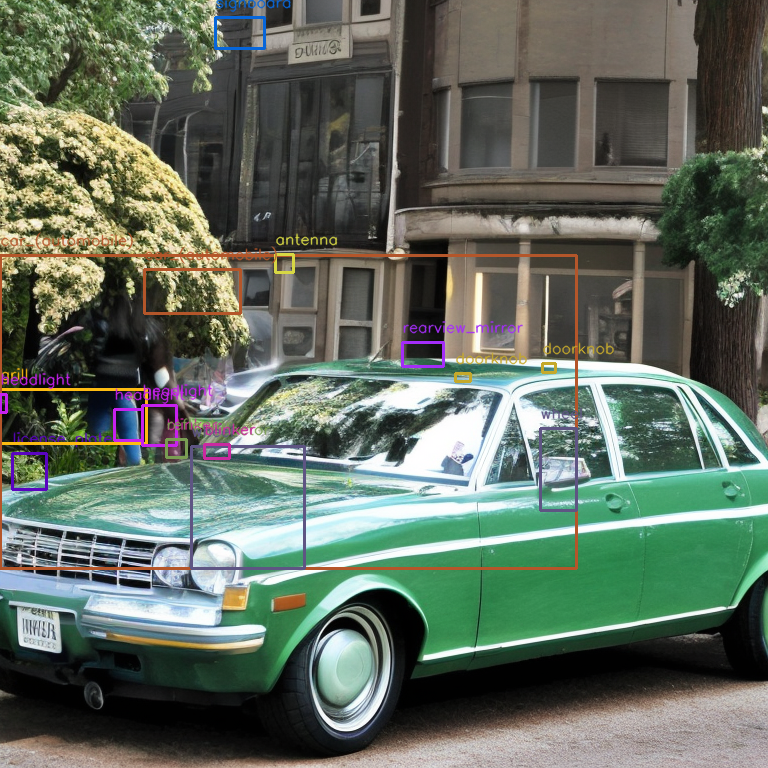

In [6]:
all_results[5]

## Image Captioning

- ImageCaptioningTesting.ipynb -> Notebook Used to identify best Captioning Model

In [26]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import numpy as np
import torch
import os

# ---------------- Dataset ----------------
class ImageDataset(Dataset):
    def __init__(self, image_dir: str, extensions=(".jpg", ".jpeg", ".png"), as_tensor=False, transform=None):
        self.image_paths = [
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith(extensions)
        ]
        self.as_tensor = as_tensor
        self.transform = transform or (T.ToTensor() if as_tensor else None)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert("RGB")

        if self.as_tensor and self.transform:
            img = self.transform(img)

        return img, path

# ---------------- Collate Function ----------------
def collate_images(batch):
    imgs, paths = zip(*batch)
    return list(imgs), list(paths)

# ---------------- Prefetching Loader ----------------
class PrefetchLoader:
    """Wrap a DataLoader to prefetch the next batch to GPU asynchronously."""
    def __init__(self, loader, device, as_tensor=False):
        self.loader = iter(loader)
        self.device = device
        self.as_tensor = as_tensor
        self.stream = torch.cuda.Stream() if device == "cuda" else None
        self.next_batch = None
        self._prefetch()

    def _prefetch(self):
        try:
            imgs, paths = next(self.loader)
        except StopIteration:
            self.next_batch = None
            return

        # Prefetching logic
        if self.device == "cuda":
            with torch.cuda.stream(self.stream):
                if self.as_tensor:
                    # Move tensors to GPU asynchronously
                    imgs = [img.to(self.device, non_blocking=True) for img in imgs]
                # else: keep PIL images on CPU (LLaVA/CLIP-style models expect CPU PILs)
        else:
            if self.as_tensor:
                imgs = [img.to(self.device) for img in imgs]

        self.next_batch = (imgs, paths)

    def __iter__(self):
        return self

    def __next__(self):
        if self.next_batch is None:
            raise StopIteration
        batch = self.next_batch
        self._prefetch()
        return batch

# ---------------- DataLoader setup ----------------
def get_image_loader(image_dir: str, batch_size=4, num_workers=4, device='cpu', as_tensor=False):
    dataset = ImageDataset(image_dir, as_tensor=as_tensor)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=False,
        collate_fn=collate_images,
        pin_memory=True
    )
    prefetch_loader = PrefetchLoader(loader, device=device, as_tensor=as_tensor)
    return prefetch_loader, len(dataset)